In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('healthcare_data_cleaning_dataset.csv')

df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [2]:
#Q1. Missing Data Identification
# Missing values in each column
missing_count = df.isnull().sum()

# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Missing Percentage': missing_percentage
})

display(missing_summary)

,Missing Values,Missing Percentage
Patient_ID,0,0.000000
Age,600,11.764706
Gender,0,0.000000
City,0,0.000000
Diagnosis,0,0.000000
Hospital_Visits,0,0.000000
Treatment_Cost,593,11.627451
Insurance_Coverage,0,0.000000
Admission_Date,0,0.000000


In [3]:
#Q2. Handling Missing Age
median_age = df['Age'].median()

print("Median Age:", median_age)

# Fill missing Age values
df['Age'] = df['Age'].fillna(median_age)

print("Missing Age after imputation:", df['Age'].isnull().sum())

Median Age: 50.0
Missing Age after imputation: 0


In [4]:
#Q3. Handling Missing Treatment Cost
median_cost = df['Treatment_Cost'].median()

print("Median Treatment Cost:", median_cost)

df['Treatment_Cost'] = df['Treatment_Cost'].fillna(median_cost)

print("Missing Treatment_Cost after imputation:",
      df['Treatment_Cost'].isnull().sum())

Median Treatment Cost: 24797.0
Missing Treatment_Cost after imputation: 0


In [5]:
#Q4. Duplicate Patient Records
# Dataset size before removing duplicates
before = len(df)

# Identify duplicate rows
duplicates = df[df.duplicated()]

print("Number of duplicate rows:", len(duplicates))

display(duplicates)

Number of duplicate rows: 99


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
5000,15126,50.0,Male,Hyderabad,Asthma,1,24797.0,1,2023-01-19
5001,15108,50.0,Male,Hyderabad,Asthma,3,24797.0,0,2023-01-27
5002,10441,50.0,Male,Chennai,Flu,3,24797.0,0,2023-07-08
5003,15975,50.0,Female,Hyderabad,Flu,10,24797.0,0,2023-06-01
5004,18427,50.0,Female,Delhi,COVID-19,13,24797.0,1,2023-03-04
...,...,...,...,...,...,...,...,...,...
5094,11571,50.0,Female,Chennai,COVID-19,4,24797.0,0,2023-01-28
5096,17597,50.0,Female,Chennai,Asthma,2,24797.0,0,2023-06-26
5097,19171,50.0,Female,Mumbai,Flu,1,24797.0,1,2023-12-31
5098,13854,50.0,Female,Bangalore,Flu,17,24797.0,0,2023-01-18


In [6]:
#Remove duplicates
df = df.drop_duplicates()

after = len(df)

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Duplicates removed:", before - after)

Rows before removing duplicates: 5100
Rows after removing duplicates: 5001
Duplicates removed: 99


In [7]:
#Q5. Invalid Age Values
invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]

print("Number of invalid age records:", len(invalid_age))

display(invalid_age)

Number of invalid age records: 0


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date


In [8]:
#Q6. Outlier Detection — Treatment Cost
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Treatment_Cost'] < lower_bound) |
    (df['Treatment_Cost'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

print("Number of outliers:", len(outliers))

display(outliers)

Q1: 13766.0
Q3: 36542.0
IQR: 22776.0
Lower Bound: -20398.0
Upper Bound: 70706.0
Number of outliers: 50


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
53,13152,91.0,Female,Chennai,COVID-19,13,199702.965333,0,2023-01-24
86,10064,28.0,Female,Hyderabad,Hypertension,16,199702.965333,0,2023-02-18
124,17035,59.0,Male,Delhi,Flu,9,199702.965333,0,2023-04-27
183,15855,36.0,Male,Mumbai,Diabetes,1,199702.965333,0,2023-01-16
215,19561,29.0,Male,Mumbai,Flu,16,199702.965333,0,2023-05-31
332,11686,51.0,Male,Delhi,Asthma,16,199702.965333,1,2023-03-31
382,10876,58.0,Female,Bangalore,Hypertension,1,199702.965333,1,2023-10-21
416,14070,50.0,Male,Hyderabad,Flu,6,199702.965333,0,2023-08-18
452,10851,42.0,Female,Bangalore,COVID-19,15,199702.965333,0,2023-06-27
796,18150,37.0,Female,Bangalore,Flu,17,199702.965333,0,2023-03-26


In [9]:
#Q7. Outlier Treatment — Winsorization
lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

print("5th Percentile:", lower_cap)
print("95th Percentile:", upper_cap)

df['Treatment_Cost_Capped'] = df['Treatment_Cost'].clip(
    lower=lower_cap,
    upper=upper_cap
)

display(df[['Treatment_Cost', 'Treatment_Cost_Capped']].head(10))

5th Percentile: 3238.0
95th Percentile: 47948.0


,Treatment_Cost,Treatment_Cost_Capped
0,41010.0,41010.0
1,12194.0,12194.0
2,45086.0,45086.0
3,40842.0,40842.0
4,9873.0,9873.0
5,11948.0,11948.0
6,31710.0,31710.0
7,25910.0,25910.0
8,24797.0,24797.0
9,3264.0,3264.0


In [10]:
#Q8. Log Transformation
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

display(df[['Treatment_Cost', 'Log_Treatment_Cost']].head(10))

,Treatment_Cost,Log_Treatment_Cost
0,41010.0,10.621596
1,12194.0,9.408781
2,45086.0,10.716349
3,40842.0,10.617491
4,9873.0,9.197660
5,11948.0,9.388403
6,31710.0,10.364419
7,25910.0,10.162423
8,24797.0,10.118518
9,3264.0,8.091015


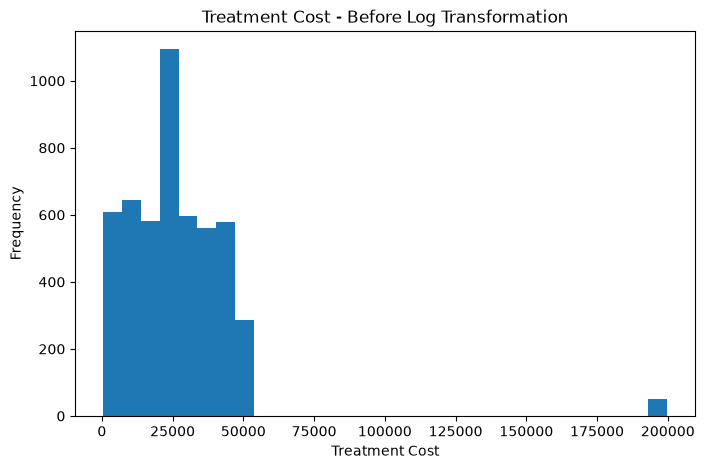

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['Treatment_Cost'], bins=30)
plt.title('Treatment Cost - Before Log Transformation')
plt.xlabel('Treatment Cost')
plt.ylabel('Frequency')
plt.show()

In [12]:
#Q9. Time-Based Missing Handling
df['Admission_Date'] = pd.to_datetime(
    df['Admission_Date'],
    errors='coerce'
)

In [13]:
df = df.sort_values('Admission_Date')

display(df[['Patient_ID', 'Admission_Date']].head(10))

,Patient_ID,Admission_Date
2932,19591,2023-01-01
4617,10896,2023-01-01
2642,19262,2023-01-01
4837,12843,2023-01-01
2702,17230,2023-01-01
329,13863,2023-01-01
348,18716,2023-01-01
4563,19175,2023-01-01
1551,10959,2023-01-01
1791,14612,2023-01-01


In [14]:
df['Admission_Date'] = df['Admission_Date'].ffill()
print("Missing Admission_Date after forward fill:",
      df['Admission_Date'].isnull().sum())

Missing Admission_Date after forward fill: 0
